<img src="./logo_UTN.svg" align="right" width="150" />

#### Teoría de Circuitos II

# Trabajo práctico de Laboratorio 2. Filtrado Digital

**Autor:** *Matías Alejandro Cruz*

**Grupo:** *1*

**Curso:** *R4052*

**Año:** *2026*

**Profesor:** *Mariano Llamedo Soria*

**Ayudante de TPs:** *David Moharos*

**Fecha de entrega:** *05/10/2026*

## 1. Objetivos
Los objetivos generales del trabajo práctico son:

- Obtener en Python los coeficientes de filtros digitales que cumplan una plantilla dada.
- Implementar los filtros en un microcontrolador STM32 NUCLEO-F446RE utilizando la librería CMSIS-DSP (`arm_fir_f32` y `arm_biquad_cascade_df1_f32`).
- Medir la respuesta en frecuencia de la cadena completa (antialiasing, ADC, filtro digital, DAC e interpolador) y compararla con la teoría.

## 2. Introducción

Este informe documenta el trabajo realizado para las plantillas A y B del TP de Laboratorio 2: un filtro pasa bajos con aproximación Chebyshev (A) y un filtro notch (B), ambos implementados de forma digital.

El flujo de la señal es el siguiente:

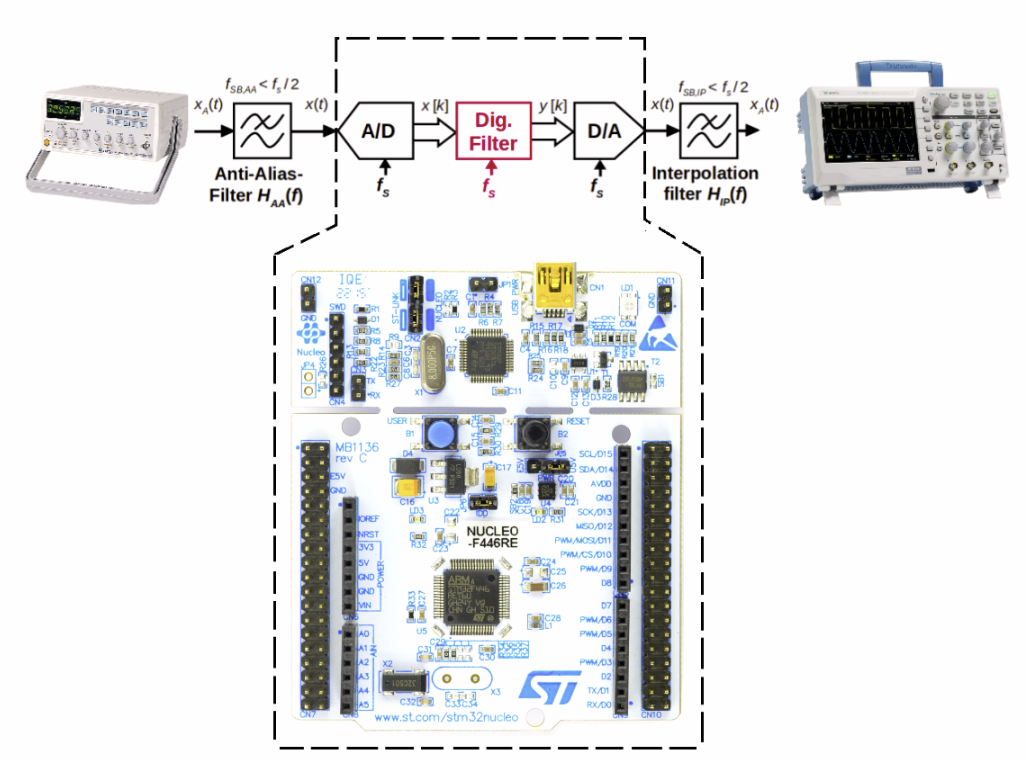

*Figura 1. Diagrama de bloques del sistema. El filtro digital corre dentro del microcontrolador, entre el conversor A/D y el D/A.*

El filtro digital es un algoritmo que corre dentro del microcontrolador. Los filtros analógicos RC de los extremos son los que acondicionan la señal para el muestreo (evitan aliasing) y suavizan los escalones del DAC (reconstrucción).

### Especificaciones de los filtros

| Filtro | Función de aproximación / tipo | $f_p$ | $f_s$ | $\alpha_{max}$ | $\alpha_{min}$ |
|---|---|---|---|---|---|
| A | Chebyshev, pasa bajos | 100 Hz | 300 Hz | 1 dB | 60 dB |

| Filtro | Tipo | $f_{notch}$ | BW @ 3 dB |
|---|---|---|---|
| B | Notch | 50 Hz | 1 Hz |

La frecuencia de muestreo del microcontrolador es $f_{s,real}$ = 1000 Hz (Nyquist = 500 Hz). Los coeficientes de cualquier filtro digital dependen de esta frecuencia, por lo que toda la simulación se escribió con $f_{s,real}$ como parámetro configurable.

El filtro A se resolvió como FIR por método de ventaneo. El filtro B se resolvió como IIR de una sola sección de segundo orden.

## 3. Diseño teórico (Pre-Lab)

### 3.1 Parámetros de diseño y filtros analógicos RC

Las frecuencias de la plantilla se normalizan respecto de la frecuencia de Nyquist ($f_{s,real}/2$), que es la convención que usan las funciones de diseño digital de `scipy.signal`. Cambiando únicamente `fs_real` se recalcula todo lo que sigue.

Los filtros analógicos de entrada y de salida son dos RC pasa bajos de primer orden idénticos, con $R\approx6900\,\Omega$ (medida con multímetro; son dos resistencias de 22 k$\Omega$ y 10 k$\Omega$ en paralelo) y $C=47\,nF$:

$$f_c=\frac{1}{2\pi RC}$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sig

plt.rcParams['figure.dpi'] = 100

# Frecuencia de muestreo del microcontrolador (parámetro configurable de toda la simulación)
fs_real = 1000.0          # Hz, igual a SAMPLE_RATE en filter.h
nyq = fs_real/2

# Plantilla A: pasa bajos Chebyshev
fp, fst = 100.0, 300.0             # Hz, borde de banda de paso y de banda de stop
alpha_max, alpha_min = 1.0, 60.0   # dB

# Plantilla B: notch
f_notch, bw_3db = 50.0, 1.0        # Hz

# Filtros analógicos RC (antialiasing y interpolador)
R = 6900.0                      # medida con multímetro (22 kOhm en paralelo con 10 kOhm, nominal 6875 Ohm)
C = 47e-9                       # capacitor marcado 473 = 47 nF
fc_rc = 1/(2*np.pi*R*C)

def G_rc_dB(f):
    """Ganancia en dB de UN filtro RC pasa bajos de primer orden."""
    return -10*np.log10(1 + (np.asarray(f, dtype=float)/fc_rc)**2)

print(f"fs = {fs_real:.0f} Hz, Nyquist = {nyq:.0f} Hz")
print(f"Plantilla A normalizada: fp = {fp/nyq:.2f}, fst = {fst/nyq:.2f}")
print(f"fc del RC = {fc_rc:.1f} Hz")
for f in [100, 200, 300, 500]:
    print(f"f = {f:3d} Hz: un RC {G_rc_dB(f):6.2f} dB, los dos RC {2*G_rc_dB(f):6.2f} dB")

fs = 1000 Hz, Nyquist = 500 Hz
Plantilla A normalizada: fp = 0.20, fst = 0.60
fc del RC = 490.8 Hz
f = 100 Hz: un RC  -0.18 dB, los dos RC  -0.35 dB
f = 200 Hz: un RC  -0.67 dB, los dos RC  -1.33 dB
f = 300 Hz: un RC  -1.38 dB, los dos RC  -2.76 dB
f = 500 Hz: un RC  -3.09 dB, los dos RC  -6.18 dB


Como los dos RC están en serie con el filtro digital (uno antes del ADC y otro después del DAC), la respuesta total del sistema es el producto de las tres respuestas, es decir, la suma en dB. Esto se tiene en cuenta más adelante al comparar con las mediciones.

### 3.2 Filtro A: FIR por ventaneo (plantilla Chebyshev)

Un pasa bajos ideal tiene una respuesta al impulso infinita (una función sinc). Para implementarlo con una cantidad finita de coeficientes se la multiplica por una ventana que vale 1 en el centro y decae hacia los bordes. La función `firwin2` recibe puntos (frecuencia, ganancia) de la plantilla, calcula esa respuesta ideal y la ventanea.

Se usaron 130 coeficientes (taps) y se compararon tres ventanas: Blackman-Harris, Hamming y Kaiser con $\beta=14$. Los puntos de la plantilla se separan de los bordes $f_p$ y $f_s$ un 12.5 % del ancho de la banda de transición (0.05 en frecuencia normalizada para $f_{s,real}$ = 1000 Hz), para que `firwin2` interpole dentro de la transición y no exactamente sobre los bordes.

In [2]:
def disenar_fir(fs_real, cant_coef=130):
    """Devuelve los taps FIR (tres ventanas) para la plantilla A con la fs_real indicada."""
    nyq = fs_real/2
    fp_n, fst_n = fp/nyq, fst/nyq
    margen = 0.125*(fst_n - fp_n)      # 0.05 cuando fs_real = 1000 Hz
    frecs = [0.0, fp_n + margen, fst_n - margen, 1.0]
    gains = 10**(np.array([0, -alpha_max, -alpha_min, -np.inf])/20)
    ventanas = {'blackmanharris': 'blackmanharris',
                'hamming': 'hamming',
                'kaiser-b14': ('kaiser', 14)}
    return {nombre: sig.firwin2(cant_coef, frecs, gains, window=v, fs=2)
            for nombre, v in ventanas.items()}

def verificar_fir(taps, fs_real):
    """Peor caída en banda de paso y menor atenuación en banda de stop, ambas en dB."""
    w, h = sig.freqz(taps, 1, worN=16384, fs=fs_real)
    g = 20*np.log10(np.abs(h) + 1e-15)
    caida = -g[w <= fp].min()
    atenuacion = -g[w >= fst].max()
    return caida, atenuacion

cant_coef = 130
fir = disenar_fir(fs_real, cant_coef)

filas = []
for nombre, taps in fir.items():
    caida, att = verificar_fir(taps, fs_real)
    filas.append({"ventana": nombre,
                  "caída máx. [dB]": round(caida, 3), "(spec <= 1)": caida <= alpha_max,
                  "atenuación mín. [dB]": round(att, 2), "(spec >= 60)": att >= alpha_min})
pd.DataFrame(filas)

,ventana,caída máx. [dB],(spec <= 1),atenuación mín. [dB],(spec >= 60)
0,blackmanharris,0.790,True,60.99,True
1,hamming,0.791,True,60.86,True
2,kaiser-b14,0.791,True,60.84,True


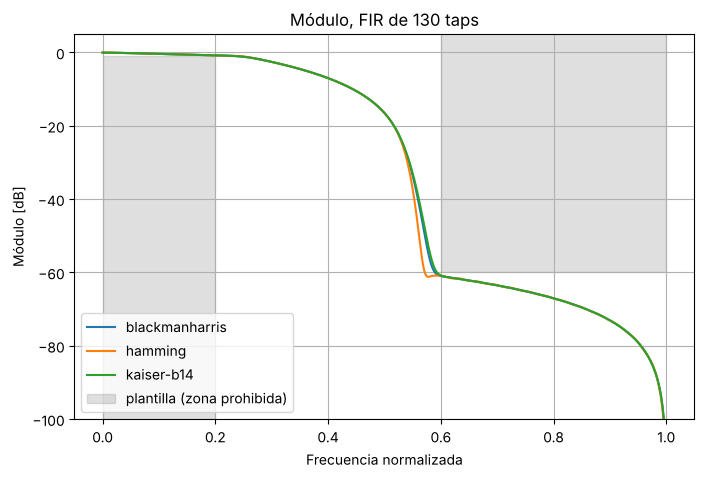

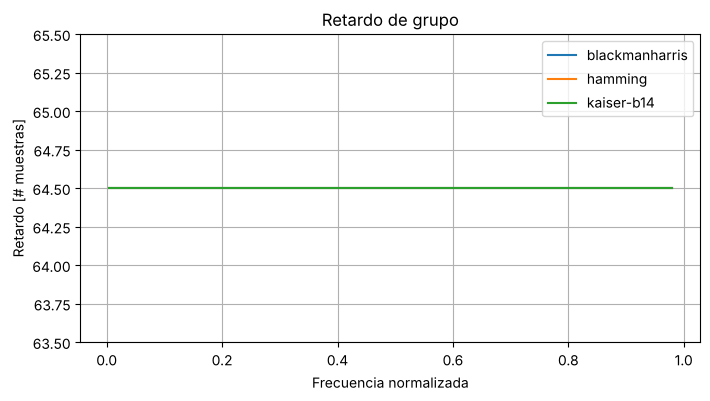

Retardo de grupo teórico (N-1)/2 = 64.5 muestras = 64.5 ms a fs = 1000 Hz


In [3]:
# Módulo con la plantilla superpuesta (frecuencia normalizada a Nyquist, como en el material de la cátedra)
fig_mod = plt.figure(figsize=(8, 5))
ax_mod = fig_mod.gca()
for nombre, taps in fir.items():
    wrad, hh = sig.freqz(taps, 1.0)
    ax_mod.plot(wrad/np.pi, 20*np.log10(np.abs(hh) + 1e-15), label=nombre)
ax_mod.fill_between([0, fp/nyq], -alpha_max, -120, color='gray', alpha=0.25)
ax_mod.fill_between([fst/nyq, 1], -alpha_min, 10, color='gray', alpha=0.25, label='plantilla (zona prohibida)')
ax_mod.set_title(f'Módulo, FIR de {cant_coef} taps')
ax_mod.set_xlabel('Frecuencia normalizada')
ax_mod.set_ylabel('Módulo [dB]')
ax_mod.set_ylim(-100, 5)
ax_mod.grid(True)
ax_mod.legend(loc='lower left')
plt.show()

# Retardo de grupo (se evita el borde de Nyquist, donde el cálculo numérico es singular)
plt.figure(figsize=(8, 4))
w_gd = np.linspace(0.01, 0.98*np.pi, 1000)
for nombre, taps in fir.items():
    _, gd = sig.group_delay((taps, 1.0), w=w_gd)
    plt.plot(w_gd/np.pi, gd, label=nombre)
plt.title('Retardo de grupo')
plt.xlabel('Frecuencia normalizada')
plt.ylabel('Retardo [# muestras]')
plt.ylim(63.5, 65.5)
plt.grid(True)
plt.legend()
plt.show()

print(f"Retardo de grupo teórico (N-1)/2 = {(cant_coef-1)/2} muestras = {(cant_coef-1)/2/fs_real*1e3:.1f} ms a fs = {fs_real:.0f} Hz")

**Resultado:** las tres ventanas cumplen la plantilla con 130 coeficientes, con una caída máxima en banda de paso de aproximadamente 0.79 dB (se permiten 1 dB) y una atenuación mínima en banda de stop de aproximadamente 61 dB (se piden 60 dB). Como los taps son simétricos, el retardo de grupo es constante e igual a $(N-1)/2=64.5$ muestras: todas las frecuencias se retrasan lo mismo y la forma de onda no se distorsiona.

**Elección de la ventana:** las tres ventanas dan resultados prácticamente idénticos (la atenuación en la banda de stop difiere en 0.02 a 0.15 dB), porque la banda de transición (100 a 300 Hz) es ancha, por lo que la elección no es determinante. Se adoptó **Kaiser con $\beta=14$**, que además permite ajustar con un solo parámetro ($\beta$) el compromiso entre el ancho de la transición y la atenuación en la banda de stop.

**Sobre la aproximación y la cantidad de coeficientes:** un FIR diseñado por ventaneo no es una aproximación Chebyshev. Cumple la misma plantilla (mismos $f_p$, $f_s$, $\alpha_{max}$ y $\alpha_{min}$), con la ventaja de tener fase lineal. Con 130 coeficientes se cumple con margen: con esta ventana alcanzan unos 114 (ver 3.5), y un FIR equiripple (Parks-McClellan, `scipy.signal.remez`) cumpliría la plantilla con una cantidad bastante menor.

No se necesita ninguna conversión de signos para cargar un FIR en CMSIS: ambas librerías definen la salida como la misma suma pesada de entradas pasadas, y un FIR no tiene realimentación.

### 3.3 Filtro B: notch como IIR de una sección

Un notch de 1 Hz de ancho sobre una frecuencia de muestreo de 1000 Hz es extremadamente angosto. Con un FIR por ventaneo requeriría miles de coeficientes, mientras que con un IIR basta un par de polos muy cercanos al círculo unitario junto con un par de ceros sobre él, es decir, una única sección de segundo orden (biquad).

El ancho de banda se especifica a través del factor de calidad:

$$Q=\frac{f_{notch}}{BW}=\frac{50}{1}=50$$

y `scipy.signal.iirnotch` devuelve los coeficientes $b$ y $a$ del filtro digital.

In [4]:
def disenar_notch(fs_real):
    Q = f_notch/bw_3db
    return sig.iirnotch(f_notch, Q, fs=fs_real)

b_notch, a_notch = disenar_notch(fs_real)
print("Q =", f_notch/bw_3db)
print("b =", b_notch)
print("a =", a_notch)

# Verificación con grilla fina (la frecuencia del mínimo y el ancho de banda a -3 dB)
f_fina = np.linspace(0, nyq, 2**20)
_, h = sig.freqz(b_notch, a_notch, worN=f_fina, fs=fs_real)
mag = 20*np.log10(np.abs(h) + 1e-300)
bajo = f_fina[mag <= -3]
print(f"Borde inferior a -3 dB = {bajo.min():.3f} Hz, borde superior = {bajo.max():.3f} Hz")
print(f"BW a -3 dB = {bajo.max() - bajo.min():.3f} Hz (especificado: {bw_3db} Hz)")
print(f"Frecuencia central = {(bajo.max() + bajo.min())/2:.3f} Hz (especificada: {f_notch} Hz)")

Q = 50.0
b = [ 0.99686824 -1.89615606  0.99686824]
a = [ 1.         -1.89615606  0.99373647]


Borde inferior a -3 dB = 49.501 Hz, borde superior = 50.503 Hz
BW a -3 dB = 1.002 Hz (especificado: 1.0 Hz)
Frecuencia central = 50.002 Hz (especificada: 50.0 Hz)


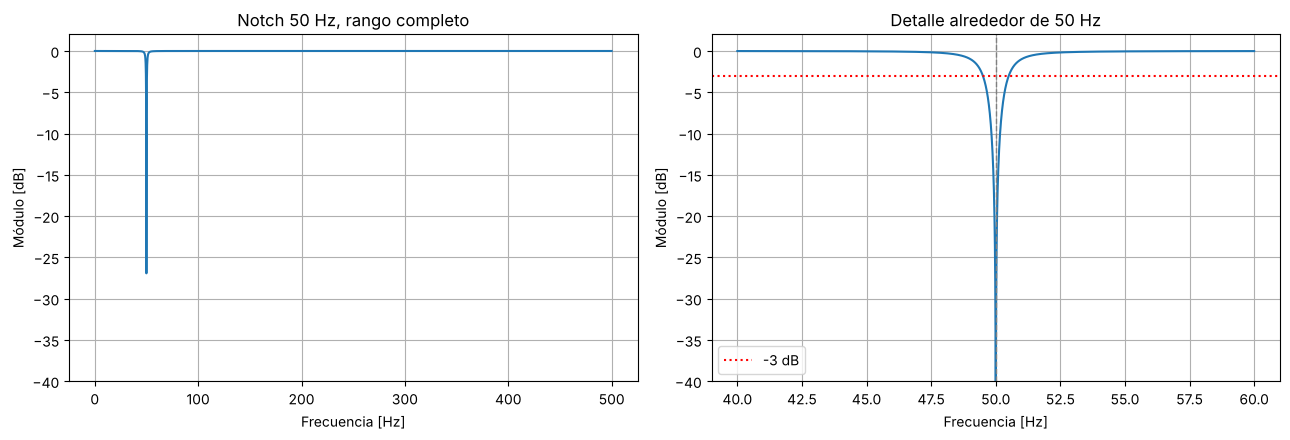

In [5]:
f_zoom = np.linspace(40, 60, 8001)
_, hz = sig.freqz(b_notch, a_notch, worN=f_zoom, fs=fs_real)
f_todo = np.linspace(0.1, nyq, 4000)
_, ht = sig.freqz(b_notch, a_notch, worN=f_todo, fs=fs_real)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(f_todo, 20*np.log10(np.abs(ht) + 1e-300))
ax1.set_ylim(-40, 2)
ax1.set_xlabel('Frecuencia [Hz]'); ax1.set_ylabel('Módulo [dB]')
ax1.set_title('Notch 50 Hz, rango completo'); ax1.grid(True)

ax2.plot(f_zoom, 20*np.log10(np.abs(hz) + 1e-300))
ax2.axhline(-3, color='red', linestyle=':', label='-3 dB')
ax2.axvline(f_notch, color='gray', linestyle='--', linewidth=1)
ax2.set_ylim(-40, 2)
ax2.set_xlabel('Frecuencia [Hz]'); ax2.set_ylabel('Módulo [dB]')
ax2.set_title('Detalle alrededor de 50 Hz'); ax2.grid(True); ax2.legend()
plt.tight_layout(); plt.show()

**Resultado:** el notch queda centrado en 50 Hz con un ancho de banda a -3 dB de 1.00 Hz. En la frecuencia central la atenuación teórica es prácticamente infinita (el valor numérico es solo el límite de la precisión de punto flotante), pero cae muy rápido al apartarse: la curva es tan angosta que cualquier desviación de la frecuencia de excitación reduce mucho la profundidad que se puede medir (sección 7.2).

### 3.4 Coeficientes en formato CMSIS-DSP

`arm_biquad_cascade_df1_f32` espera, para cada sección, los cinco valores `{b0, b1, b2, a1, a2}` y calcula

$$y[n]=b_0x[n]+b_1x[n-1]+b_2x[n-2]+a_1y[n-1]+a_2y[n-2]$$

mientras que `scipy` escribe $a_0y[n]+a_1y[n-1]+a_2y[n-2]=b_0x[n]+b_1x[n-1]+b_2x[n-2]$ con $a_0=1$. Por eso los coeficientes del denominador de `scipy` deben cambiarse de signo antes de pasarlos al microcontrolador. Esta conversión se hace una sola vez, en Python, en tiempo de diseño: el código C solo contiene constantes ya convertidas.

In [6]:
def sos_to_cmsis(sos):
    """Cada sección de scipy [b0 b1 b2 a0 a1 a2] pasa a CMSIS [b0 b1 b2 -a1 -a2] (con a0 = 1)."""
    sos = np.asarray(sos, dtype=float)
    return np.column_stack([sos[:, 0], sos[:, 1], sos[:, 2], -sos[:, 4], -sos[:, 5]])

def imprimir_c(declaracion, valores, por_linea=5):
    valores = np.ravel(valores)
    print(declaracion + " = {")
    for i in range(0, len(valores), por_linea):
        print("    " + ", ".join(f"{v:.10f}f" for v in valores[i:i+por_linea]) + ",")
    print("};")

# Notch: una sección
sos_notch = sig.tf2sos(b_notch, a_notch)
cmsis_notch = sos_to_cmsis(sos_notch)
imprimir_c("float32_t float_iir_taps[IIR_SOS_NUM * 5]", cmsis_notch)

# Comprobación contra la conversión manual: a1_cmsis = -a1_scipy, a2_cmsis = -a2_scipy
manual = [b_notch[0], b_notch[1], b_notch[2], -a_notch[1], -a_notch[2]]
print("Coincide con la conversión manual:", np.allclose(cmsis_notch[0], manual))

float32_t float_iir_taps[IIR_SOS_NUM * 5] = {
    0.9968682358f, -1.8961560630f, 0.9968682358f, 1.8961560630f, -0.9937364715f,
};
Coincide con la conversión manual: True


In [7]:
# Filtro A (FIR, ventana Kaiser): los taps se cargan tal cual, sin conversión
imprimir_c("float32_t float_fir_taps[FIR_TAP_NUM]", fir['kaiser-b14'], por_linea=5)
print(f"\nFIR_TAP_NUM = {len(fir['kaiser-b14'])}, IIR_SOS_NUM = {cmsis_notch.shape[0]}")

float32_t float_fir_taps[FIR_TAP_NUM] = {
    0.0000000006f, 0.0000000036f, 0.0000000005f, -0.0000000088f, -0.0000000004f,
    -0.0000000004f, -0.0000000431f, 0.0000000068f, 0.0000001900f, 0.0000001519f,
    -0.0000001051f, 0.0000000125f, 0.0000001068f, -0.0000006622f, -0.0000007192f,
    0.0000012632f, 0.0000019964f, 0.0000000683f, 0.0000005697f, 0.0000023860f,
    -0.0000027541f, -0.0000077617f, 0.0000011786f, 0.0000100446f, 0.0000028656f,
    0.0000035035f, 0.0000190200f, 0.0000035125f, -0.0000346660f, -0.0000189814f,
    0.0000255664f, 0.0000093792f, 0.0000010678f, 0.0000801878f, 0.0000809204f,
    -0.0000733085f, -0.0001084967f, 0.0000302815f, 0.0000068186f, -0.0000801694f,
    0.0001861903f, 0.0004127204f, 0.0000239511f, -0.0003110286f, 0.0000012971f,
    0.0000018173f, -0.0005150133f, 0.0000547086f, 0.0013469028f, 0.0008568389f,
    -0.0005284697f, 0.0000646275f, 0.0004174852f, -0.0021339761f, -0.0021417962f,
    0.0035475029f, 0.0053942519f, 0.0000609203f, 0.0015955442f, 0.0077

### 3.5 Simulación con frecuencia de muestreo configurable

Para mostrar por qué la frecuencia de muestreo tiene que ser un parámetro, se repite el diseño para otras $f_{s,real}$ con las mismas frecuencias físicas de la plantilla. Al aumentar $f_{s,real}$ la banda de transición (100 a 300 Hz) ocupa una fracción menor del eje normalizado, así que un FIR de 130 taps deja de alcanzar y hace falta más orden. El notch, en cambio, sigue siendo una sola sección pero con coeficientes distintos.

In [8]:
def orden_minimo_kaiser(fs_real, paso=2, n_max=4000):
    for n in range(20, n_max, paso):
        taps = disenar_fir(fs_real, n)['kaiser-b14']
        caida, att = verificar_fir(taps, fs_real)
        if caida <= alpha_max and att >= alpha_min:
            return n
    return None

filas = []
for fs_test in [1000.0, 2000.0, 4000.0]:
    caida, att = verificar_fir(disenar_fir(fs_test, 130)['kaiser-b14'], fs_test)
    b_t, a_t = disenar_notch(fs_test)
    filas.append({"fs [Hz]": fs_test,
                  "FIR 130 taps: caída [dB]": round(caida, 2),
                  "FIR 130 taps: atenuación [dB]": round(att, 1),
                  "cumple con 130": (caida <= alpha_max) and (att >= alpha_min),
                  "taps mínimos (Kaiser)": orden_minimo_kaiser(fs_test),
                  "notch a1 (CMSIS)": round(-a_t[1], 6)})
pd.DataFrame(filas)

,fs [Hz],FIR 130 taps: caída [dB],FIR 130 taps: atenuación [dB],cumple con 130,taps mínimos (Kaiser),notch a1 (CMSIS)
0,1000.0,0.79,60.8,True,114,1.896156
1,2000.0,0.82,46.1,False,252,1.972279
2,4000.0,1.05,29.8,False,528,1.992270


## 4. Implementación en el microcontrolador

Se utilizó el proyecto base de la cátedra para la NUCLEO-F446RE (STM32CubeIDE), en el que ya están resueltos la adquisición y la reconstrucción. Su funcionamiento es el siguiente:

- Un timer (TIM2) dispara cada conversión del ADC por hardware a la frecuencia `SAMPLE_RATE` (1000 Hz).
- El ADC1 convierte el canal 0 (pin PA0, A0) con 12 bits. En el callback de cada conversión se resta 2048 (la mitad de la escala) para trabajar con una señal centrada en cero, y se escribe en el DAC (canal 1, pin PA4) la muestra ya procesada del bloque anterior, sumándole 2048 para volver a la escala unipolar.
- Se trabaja por bloques de 1024 muestras con dos buffers (ping-pong): mientras un bloque se llena con muestras nuevas, el otro se filtra y se va entregando al DAC. En el lazo principal, `app_update()` aplica sobre el bloque completo el filtro elegido.
- La variable `filter` selecciona el procesamiento: `TALKTHROUGH` (copia la entrada a la salida, sin filtrar), `FIR` (`arm_fir_f32`) o `IIR` (`arm_biquad_cascade_df1_f32`).

Las modificaciones realizadas fueron: cargar los 130 taps del filtro A en `float_fir_taps[]` con `FIR_TAP_NUM = 130`; cargar la sección del notch en `float_iir_taps[]` con `IIR_SOS_NUM = 1` (eliminando el placeholder original `float_iir_taps[IIR_TAP_NUM]`, que producía una declaración duplicada); y dejar tres líneas para elegir el filtro, de las cuales solo una está activa:

```c
filter_type_t filter = TALKTHROUGH;
//filter_type_t filter = FIR;   // Filtro A
//filter_type_t filter = IIR;   // Filtro B
```

Configuración del ADC y del muestreo (según el `main.c` del proyecto): el ADC1 convierte el canal 0 (PA0) con 12 bits y tiempo de muestreo `ADC_SAMPLETIME_3CYCLES` (el valor por defecto del proyecto, no se modificó), disparado por el timer TIM2 a una frecuencia de 1 kHz.

Conexiones del kit:

| Pin | Descripción |
|---|---|
| CN6 - pin 6 | GND |
| CN6 - pin 4 | +5 VDC |
| CN8 - pin 1 (A0, PA0) | ADC_IN |
| CN8 - pin 3 (A2, PA4) | DAC_OUT |

## 5. Diseño de hardware

### 5.1 Filtros RC

Los dos filtros (antialiasing a la entrada del ADC e interpolador a la salida del DAC) son idénticos: un pasa bajos RC de primer orden, con la resistencia en serie con la señal y el capacitor desde el nodo de salida a masa.

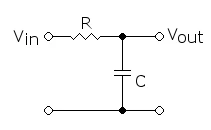

*Figura 2. Esquema del filtro RC pasa bajos utilizado en la entrada y en la salida.*

| Componente | Valor |
|---|---|
| Resistencia R | Dos resistores en paralelo: 22 k$\Omega$ (rojo, rojo, naranja, dorado) y 10 k$\Omega$ (marrón, negro, naranja, dorado), ambos de 5 %. Equivalente nominal: 6.875 k$\Omega$. Medida con multímetro: 6.9 k$\Omega$ |
| Capacitor C | Cerámico marcado 473, es decir, 47 nF |
| Frecuencia de corte $f_c=\frac{1}{2\pi RC}$ | 490.8 Hz (con R = 6.9 k$\Omega$) |

Los valores de diseño eran 6.8 k$\Omega$ y 46 nF (fc de 508.8 Hz), pero no se contaba con esos componentes, por lo que se armaron con los disponibles. El valor de R se midió con multímetro (el nominal es 6.875 k$\Omega$) y el de C es el nominal según el marcado. La frecuencia de corte queda cercana a la frecuencia de Nyquist (500 Hz). Esto es una limitación del diseño: a 500 Hz cada RC atenúa solo unos 3 dB, por lo que el filtro de antialiasing es débil. En el filtro de entrada, la señal proviene del generador y la salida va al pin del ADC; en el de salida, la entrada es el pin del DAC y la salida va al osciloscopio.

### 5.2 Placa armada

Los filtros se montaron sobre una placa experimental perforada de 9 x 15 cm, soldada a mano. Sobre la placa hay:

- Dos tiras de pines hembra que reproducen los conectores de la NUCLEO-F446RE (CN7 y CN8 a la izquierda, CN9 y CN10 a la derecha), de modo que la placa del microcontrolador se encastra directamente.
- Los dos filtros RC (cada uno con dos resistores en paralelo de 22 kΩ y 10 kΩ y un capacitor de 47 nF).
- Tiras de pines adicionales usadas como terminales para conectar el generador y el osciloscopio.

En la primera foto se ven los dos filtros RC y los conectores, y en la segunda la NUCLEO ya encastrada sobre la placa.

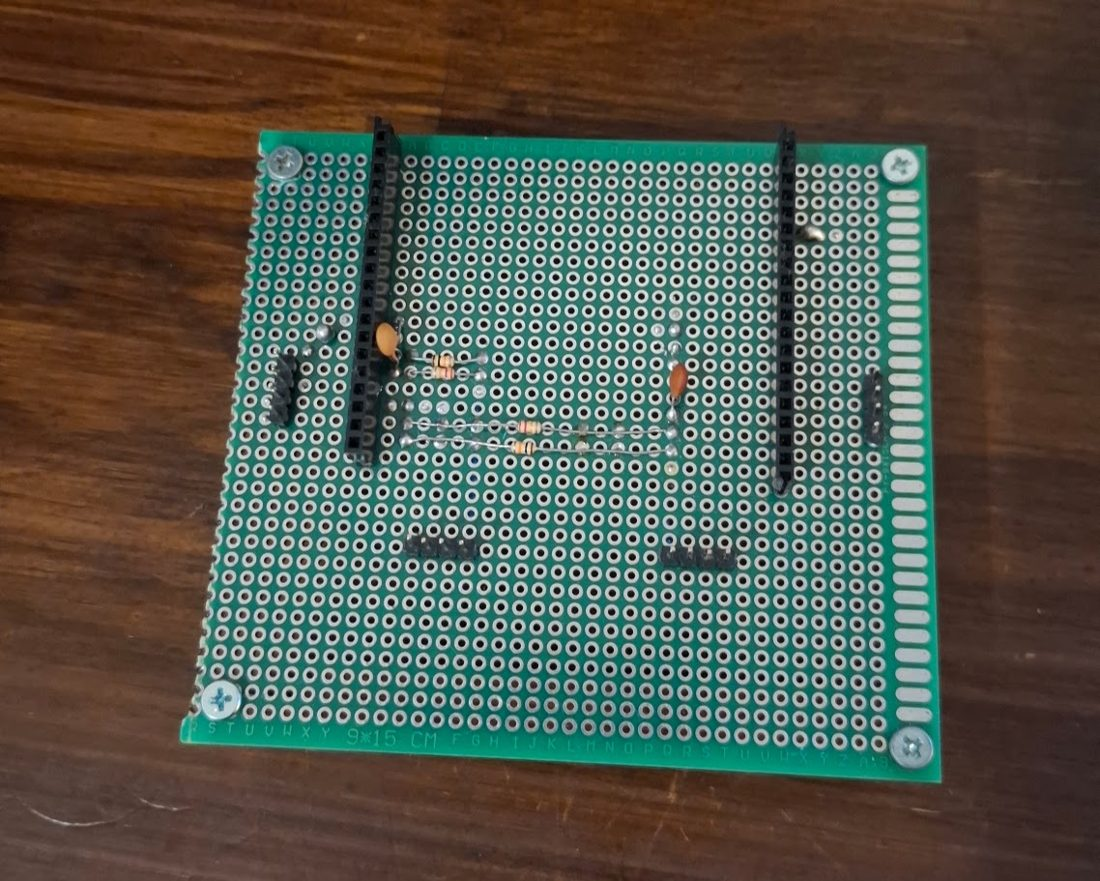

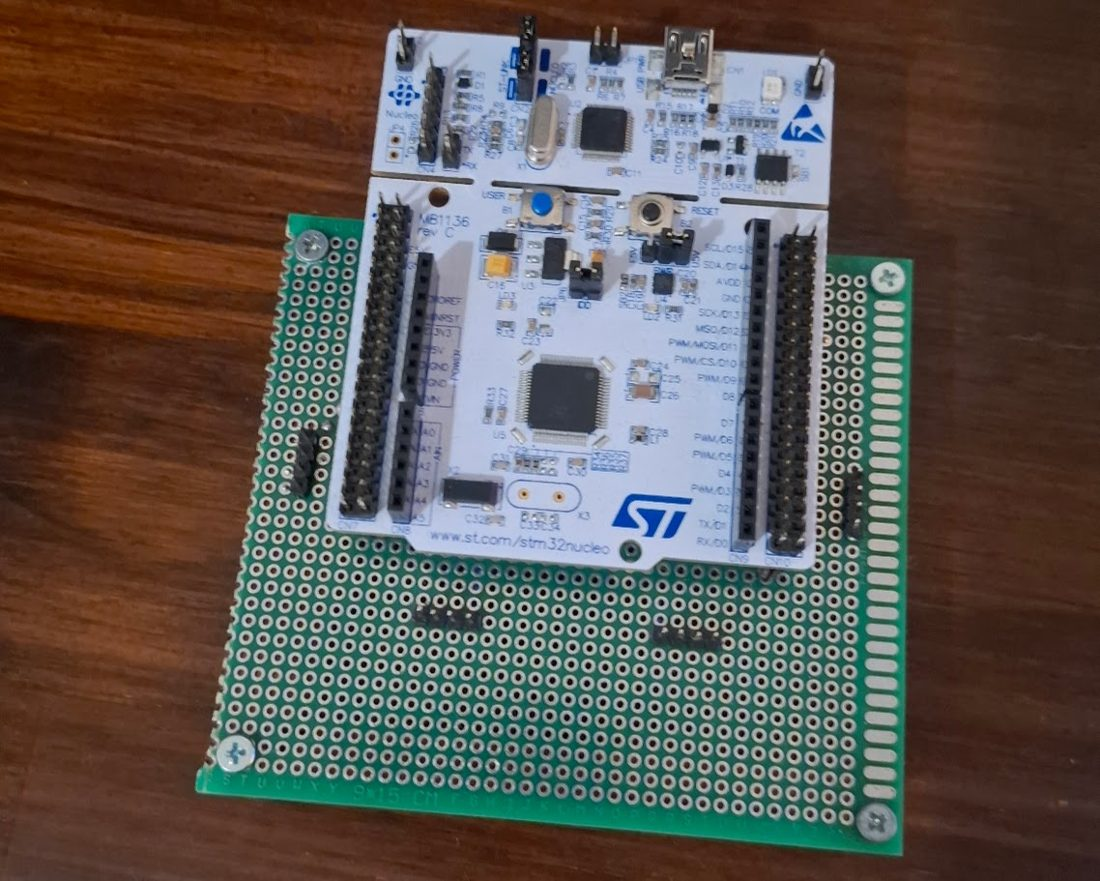

## 6. Procedimiento experimental

###  6.1 Instrumental utilizado

| Instrumento | Tipo | Fabricante | Modelo | N° Serie |
|---|---|---|---|---|
| Kit de desarrollo | NUCLEO-F446RE (programación por ST-LINK) | STMicroelectronics | NUCLEO-F446RE | S/N |
| Señal de entrada | Generador de señales senoidales hasta 5MHz | Twintex | TFG-3205E | NG 1906 |
| Osciloscopio | Osciloscopio digital de 70MHz, 1G Sa/s | GW Instek | GDS-10772A-U | NG 1393 |
| Analizador de audio | Generador y analizador de audio (barrido de frecuencia) | Agilent Technologies | U8903A | NG 1652 |

###  6.2 Método de medición

La entrada se excitó con un generador de funciones en modo senoidal, con amplitud fija de aproximadamente 3 V pico a pico y un offset de continua ajustado para que la señal quede centrada en la escala del ADC (0 a 3.3 V) sin recortarse. En el canal 1 del osciloscopio se midió la señal de entrada y en el canal 2 la salida, a la salida del filtro interpolador. Las tablas de las secciones 7.2 y 7.3 se tomaron de este modo, un punto por vez, con generador de funciones y osciloscopio.

Para cada frecuencia se registraron las tensiones pico a pico de entrada ($V_i$) y de salida ($V_o$), y se calculó la ganancia:

$$G=20\log_{10}\left(\frac{V_o}{V_i}\right)$$

Se midió cada filtro por separado, recompilando y reprogramando el micro con la línea correspondiente de `filter` activa. En cada barrido se tomaron más puntos en el entorno de las frecuencias críticas de la plantilla (100 y 300 Hz para el filtro A, y alrededor de 50 Hz para el notch).

Además, para el notch se repitió la medición en el laboratorio con un analizador de audio (generador y medidor en un mismo equipo), con la expectativa de ganar precisión: al generar la señal y medir la salida el mismo instrumento, la frecuencia de excitación es más exacta y conocida que con el generador de funciones usado en las tablas. En este caso se hizo un barrido (sección 7.2.1), no una medición por frecuencia fija.

Como el sistema medido incluye los dos RC analógicos además del filtro digital, se calculó la respuesta teórica del sistema completo como la suma en dB de la respuesta del filtro digital y la de los dos RC. También se verificó la cadena en modo `TALKTHROUGH` (sección 7.1). Las tensiones se leyeron con una resolución de aproximadamente 0.04 V, lo que equivale a unos ±0.1 dB sobre una señal de 3 V.

## 7. Resultados experimentales

### 7.1 Verificación de la cadena en modo TALKTHROUGH

Con el procesamiento digital desactivado (`filter = TALKTHROUGH`) la señal solo debe atravesar el ADC, el DAC y los dos RC. La captura corresponde a una senoidal de aproximadamente 110 Hz: el canal 1 (amarillo) es la entrada y el canal 2 (celeste) la salida del interpolador, donde se ven los escalones del DAC que el RC de un solo polo no llega a eliminar del todo a esa frecuencia (hay solo unas 9 muestras por ciclo).

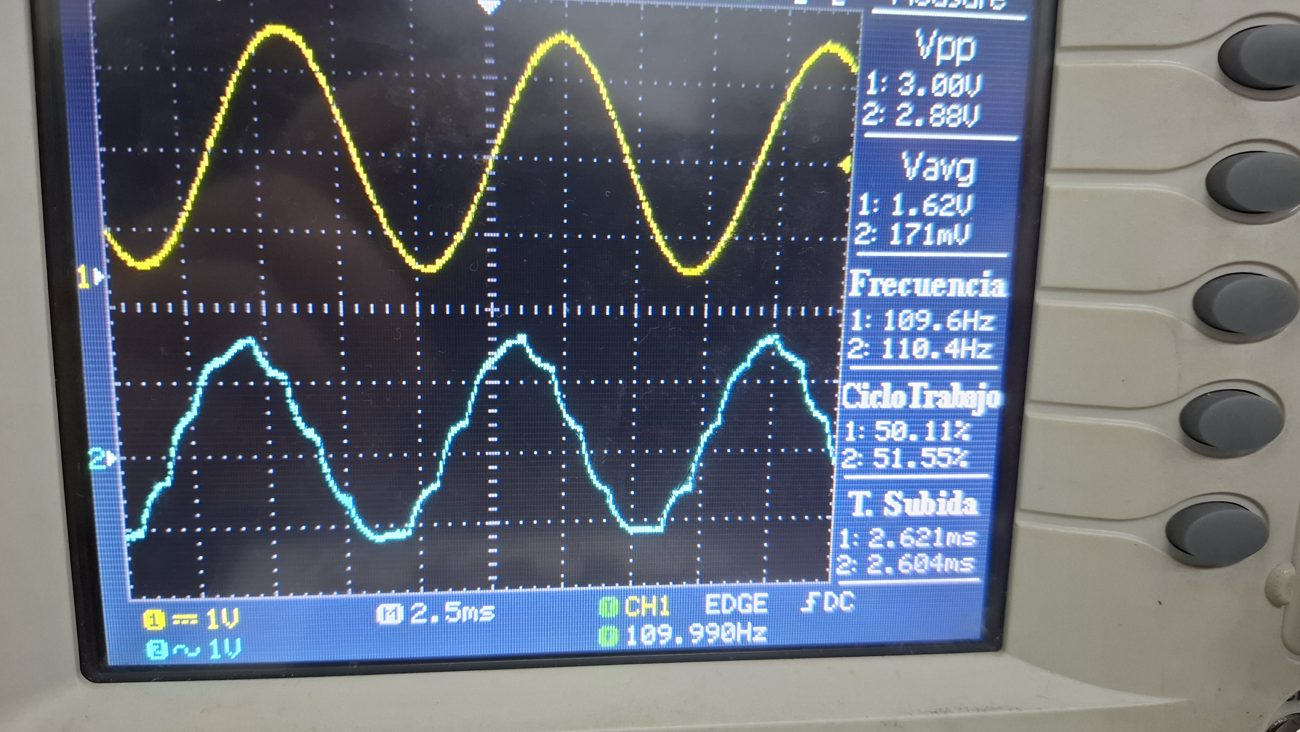

In [9]:
Vi_tt, Vo_tt, f_tt = 3.00, 2.88, 110.0     # valores leídos en la captura (Vpp)
G_med_tt = 20*np.log10(Vo_tt/Vi_tt)
G_teo_tt = 2*G_rc_dB(f_tt)
print(f"Ganancia medida en TALKTHROUGH a {f_tt:.0f} Hz = {G_med_tt:.2f} dB")
print(f"Ganancia teórica de los dos RC a {f_tt:.0f} Hz = {G_teo_tt:.2f} dB")

Ganancia medida en TALKTHROUGH a 110 Hz = -0.35 dB
Ganancia teórica de los dos RC a 110 Hz = -0.43 dB


La ganancia medida coincide con la que aportan solamente los dos RC (diferencia de una fracción de dB), lo que indica que el ADC, el DAC y el firmware no agregan atenuación apreciable y que todo lo que se vea en los barridos siguientes debe provenir del filtro digital y de los RC.

### 7.2 Filtro B (notch)

In [10]:
medicion_B = pd.DataFrame({
    "freq": [10, 20, 30, 35, 40, 45, 46, 48, 50, 51, 52, 55, 60, 80, 100],
    "Vi":   [3.07, 3.03, 3.07, 3.03, 3.03, 3.07, 3.03, 3.03, 3.07, 3.03, 3.07, 3.03, 3.03, 3.00, 3.00],
    "Vo":   [2.83, 3.00, 3.00, 3.00, 3.00, 3.00, 3.00, 2.92, 0.52, 2.59, 2.92, 3.00, 3.00, 3.00, 2.96],
})   # Vi y Vo en V pico a pico

medicion_B["G_med_dB"] = 20*np.log10(medicion_B["Vo"]/medicion_B["Vi"])

# Teoría: notch digital y sistema completo (notch + dos RC)
_, hB = sig.freqz(b_notch, a_notch, worN=medicion_B["freq"].values, fs=fs_real)
medicion_B["G_notch_teo_dB"] = 20*np.log10(np.abs(hB) + 1e-300)
medicion_B["G_RCx2_dB"] = 2*G_rc_dB(medicion_B["freq"])
medicion_B["G_sistema_teo_dB"] = medicion_B["G_notch_teo_dB"] + medicion_B["G_RCx2_dB"]
medicion_B["error_dB"] = medicion_B["G_med_dB"] - medicion_B["G_sistema_teo_dB"]
medicion_B.round(2)

,freq,Vi,Vo,G_med_dB,G_notch_teo_dB,G_RCx2_dB,G_sistema_teo_dB,error_dB
0,10,3.07,2.83,-0.71,-0.00,-0.00,-0.00,-0.70
1,20,3.03,3.00,-0.09,-0.00,-0.01,-0.01,-0.07
2,30,3.07,3.00,-0.20,-0.00,-0.03,-0.03,-0.17
3,35,3.03,3.00,-0.09,-0.00,-0.04,-0.05,-0.04
4,40,3.03,3.00,-0.09,-0.01,-0.06,-0.07,-0.02
5,45,3.07,3.00,-0.20,-0.04,-0.07,-0.11,-0.09
6,46,3.03,3.00,-0.09,-0.06,-0.08,-0.14,0.05
7,48,3.03,2.92,-0.32,-0.25,-0.08,-0.34,0.01
8,50,3.07,0.52,-15.42,-264.36,-0.09,-264.45,249.02
9,51,3.03,2.59,-1.36,-0.99,-0.09,-1.08,-0.28


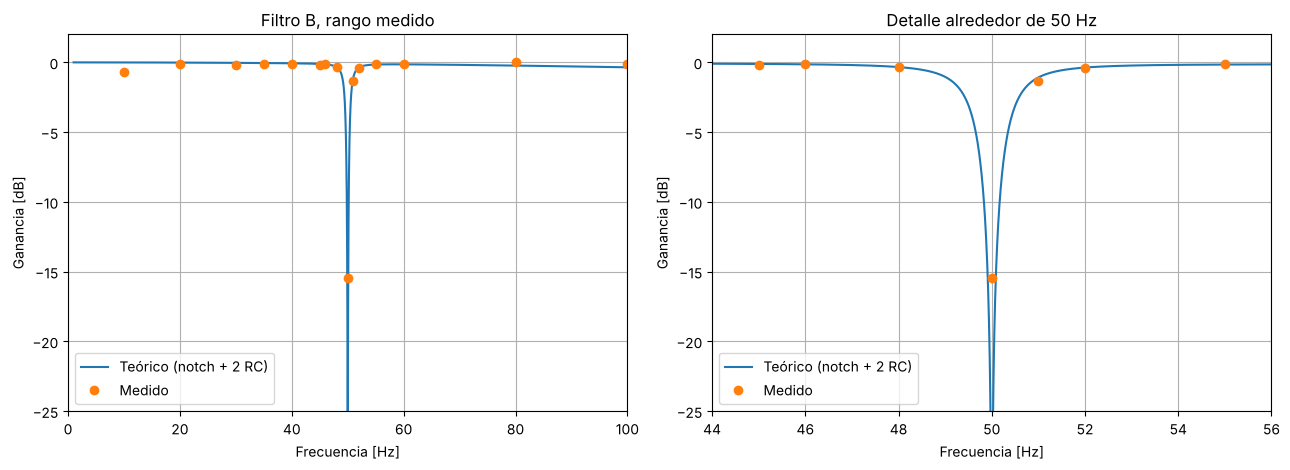

In [11]:
f_a = np.linspace(1, 100, 4000)
_, h_a = sig.freqz(b_notch, a_notch, worN=f_a, fs=fs_real)
G_sis_a = 20*np.log10(np.abs(h_a) + 1e-300) + 2*G_rc_dB(f_a)

f_b = np.linspace(44, 56, 6001)
_, h_b = sig.freqz(b_notch, a_notch, worN=f_b, fs=fs_real)
G_sis_b = 20*np.log10(np.abs(h_b) + 1e-300) + 2*G_rc_dB(f_b)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, f_t, G_t, xlim in [(ax1, f_a, G_sis_a, (0, 100)), (ax2, f_b, G_sis_b, (44, 56))]:
    ax.plot(f_t, G_t, label='Teórico (notch + 2 RC)')
    ax.plot(medicion_B["freq"], medicion_B["G_med_dB"], 'o', label='Medido')
    ax.set_xlim(*xlim); ax.set_ylim(-25, 2)
    ax.set_xlabel('Frecuencia [Hz]'); ax.set_ylabel('Ganancia [dB]')
    ax.grid(True); ax.legend()
ax1.set_title('Filtro B, rango medido')
ax2.set_title('Detalle alrededor de 50 Hz')
plt.tight_layout(); plt.show()

In [12]:
# Desafinación de la frecuencia de excitación que explicaría la profundidad medida en 50 Hz
fila50 = medicion_B[medicion_B["freq"] == 50].iloc[0]
prof_dig_med = fila50["G_med_dB"] - fila50["G_RCx2_dB"]       # descontando los RC
f_barrido = np.linspace(49.5, 50.0, 500001)
_, h_barrido = sig.freqz(b_notch, a_notch, worN=f_barrido, fs=fs_real)
g_barrido = 20*np.log10(np.abs(h_barrido) + 1e-300)
idx = np.argmin(np.abs(g_barrido - prof_dig_med))
print(f"Profundidad medida en 50 Hz (sistema completo) = {fila50['G_med_dB']:.2f} dB")
print(f"Profundidad del notch digital estimada (sin los RC) = {prof_dig_med:.2f} dB")
print(f"Desafinación que daría esa profundidad: {50 - f_barrido[idx]:.3f} Hz")

Profundidad medida en 50 Hz (sistema completo) = -15.42 dB
Profundidad del notch digital estimada (sin los RC) = -15.33 dB
Desafinación que daría esa profundidad: 0.087 Hz


**Resultado:** fuera del entorno de 50 Hz la ganancia es prácticamente 0 dB (apenas los -0.1 dB que aportan los RC a las frecuencias más altas) y en 50 Hz aparece el pique del notch, con una atenuación medida de 15.4 dB. Alrededor del notch (48, 51 y 52 Hz) el sistema medido sigue a la curva teórica dentro de unos 0.3 dB, lo que confirma que la forma y el ancho del filtro implementado son los diseñados.

La profundidad medida (15.4 dB) es mucho menor que la teórica porque el notch es muy angosto ($Q=50$): con un ancho de banda de 1 Hz, una diferencia de solo unos 0.09 Hz entre la frecuencia de excitación y el centro real del notch ya reduce la atenuación a ese valor. Esa diferencia puede deberse a la precisión en frecuencia del generador y también a que el centro real del notch no sea exactamente 50.00 Hz (ver 7.2.1). La profundidad también depende del tiempo de espera tras cambiar la frecuencia: la salida del micro llega con unos 2 s de retraso y el notch, por ser tan angosto, tarda en alcanzar su régimen (constante de tiempo de unos 0.3 s). En una simulación, con la frecuencia exacta de 50 Hz la atenuación recién llega a unos 15 dB aproximadamente 0.55 s después de que la señal entra al filtro y supera los 50 dB pasados 2 s, de modo que una espera corta daría una profundidad menor que la real. Para medir más profundo habría que recorrer el entorno de 50 Hz con pasos de 0.1 Hz o menos y esperar varios segundos en cada punto.

El ancho de banda a -3 dB no pudo medirse con este barrido, ya que el paso entre puntos alrededor de 50 Hz es de 1 Hz. El punto de 10 Hz (-0.7 dB) se aparta de la teoría (0 dB) y no se investigó la causa; como a 20 Hz y más ya coincide, tiene poco peso en el resultado.

#### 7.2.1 Captura con el analizador de audio

Además del barrido punto a punto, se registró la respuesta del notch con el analizador de audio, en un barrido lineal de 48 a 53 Hz con escala vertical de 3 dB/div.

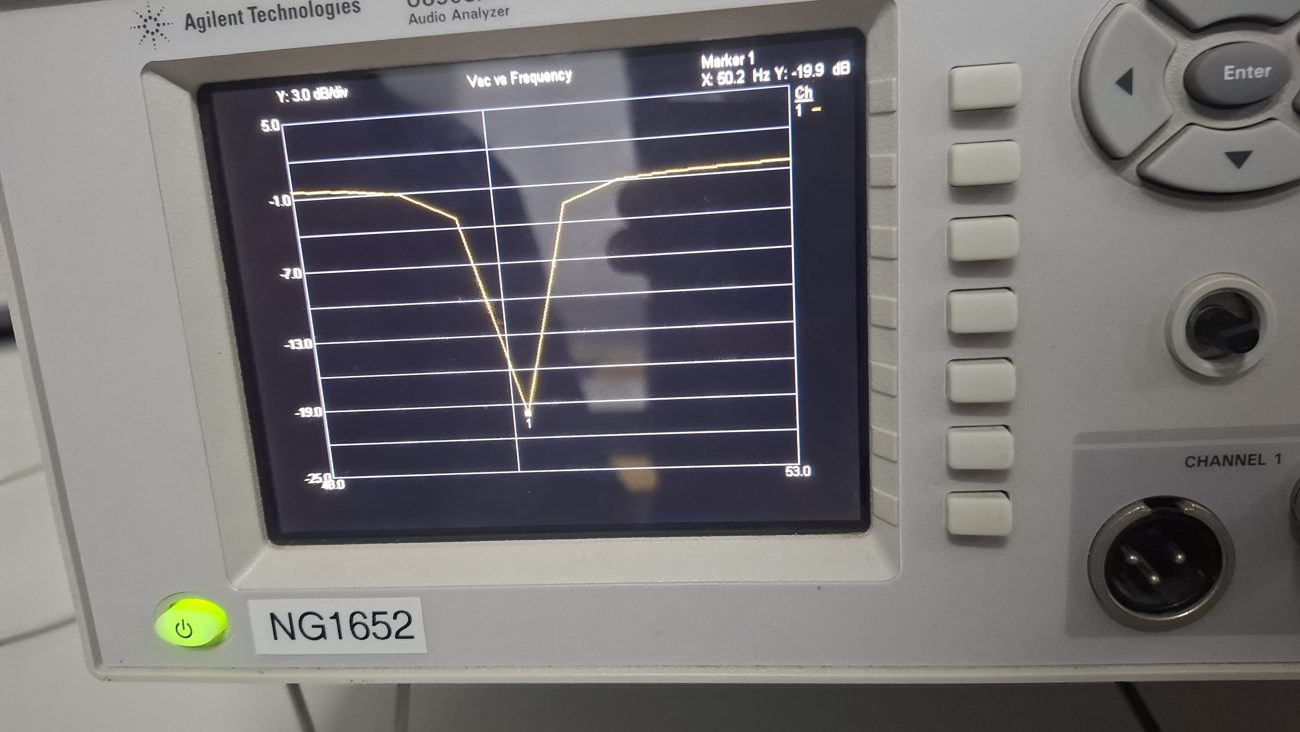

| Dato leído en la captura | Valor |
|---|---|
| Rango de frecuencia | 48 a 53 Hz |
| Escala vertical | 3 dB/div |
| Marcador 1 (mínimo) | 50.2 Hz, -19.9 dB |

La forma coincide con la del notch teórico: ganancia cercana a 0 dB a ambos lados, una caída que empieza unos 2 Hz antes del centro y un mínimo muy angosto. Dos observaciones sobre los valores:

- **Profundidad:** la curva está dibujada con pocos puntos (se distinguen los tramos rectos), por lo que el valor del mínimo (-19.9 dB) depende de si algún punto del barrido cayó justo sobre el centro del notch. Por eso no se toma como la profundidad real del filtro, sino como una cota inferior de lo que el filtro es capaz de atenuar, y es del orden de lo medido punto a punto (15.4 dB).
- **Frecuencia del mínimo:** el marcador queda en 50.2 Hz y no en 50.0 Hz, que es donde la teoría ubica el centro. La diferencia es de 0.2 Hz (0.4 %). Una posible causa es el retardo de unos 2 s del micro (ver 7.3.1): si el barrido cambia de frecuencia con poca espera, el mínimo se desplaza hacia frecuencias más altas. No se descarta un error en la frecuencia de muestreo real, que no se midió.

La desviación de 0.2 Hz está bien dentro del ancho de banda de 1 Hz, por lo que el filtro cumple la especificación de frecuencia central de la plantilla B.

### 7.3 Filtro A (plantilla Chebyshev, FIR)

In [13]:
medicion_A = pd.DataFrame({
    "freq": [20, 50, 80, 100, 120, 140, 160, 180, 200, 220, 250, 280, 300],
    "Vi":   [3.07, 3.03, 3.00, 3.00, 3.03, 3.03, 3.03, 3.03, 3.03, 3.03, 3.07, 3.07, 3.07],
    "Vo":   [2.96, 2.88, 2.79, 2.68, 2.48, 2.16, 1.84, 1.44, 1.12, 0.80, 0.368, 0.04, 0.02],
})   # Vi y Vo en V pico a pico

medicion_A["G_med_dB"] = 20*np.log10(medicion_A["Vo"]/medicion_A["Vi"])

taps_A = fir['kaiser-b14']
_, hA = sig.freqz(taps_A, 1, worN=medicion_A["freq"].values, fs=fs_real)
medicion_A["G_FIR_teo_dB"] = 20*np.log10(np.abs(hA))
medicion_A["G_RCx2_dB"] = 2*G_rc_dB(medicion_A["freq"])
medicion_A["G_sistema_teo_dB"] = medicion_A["G_FIR_teo_dB"] + medicion_A["G_RCx2_dB"]
medicion_A["error_dB"] = medicion_A["G_med_dB"] - medicion_A["G_sistema_teo_dB"]
# Estimación de la respuesta del filtro digital solo: se descuentan los RC teóricos a lo medido
medicion_A["G_FIR_estimado_dB"] = medicion_A["G_med_dB"] - medicion_A["G_RCx2_dB"]
medicion_A.round(2)

,freq,Vi,Vo,G_med_dB,G_FIR_teo_dB,G_RCx2_dB,G_sistema_teo_dB,error_dB,G_FIR_estimado_dB
0,20,3.07,2.96,-0.32,-0.15,-0.01,-0.17,-0.15,-0.30
1,50,3.03,2.88,-0.44,-0.39,-0.09,-0.48,0.03,-0.35
2,80,3.00,2.79,-0.63,-0.63,-0.23,-0.85,0.22,-0.40
3,100,3.00,2.68,-0.98,-0.79,-0.35,-1.14,0.16,-0.63
4,120,3.03,2.48,-1.74,-1.04,-0.50,-1.54,-0.20,-1.24
5,140,3.03,2.16,-2.94,-1.92,-0.68,-2.60,-0.34,-2.26
6,160,3.03,1.84,-4.33,-3.30,-0.88,-4.18,-0.15,-3.46
7,180,3.03,1.44,-6.46,-4.96,-1.10,-6.06,-0.40,-5.37
8,200,3.03,1.12,-8.64,-7.01,-1.33,-8.35,-0.30,-7.31
9,220,3.03,0.80,-11.57,-9.70,-1.59,-11.29,-0.28,-9.98


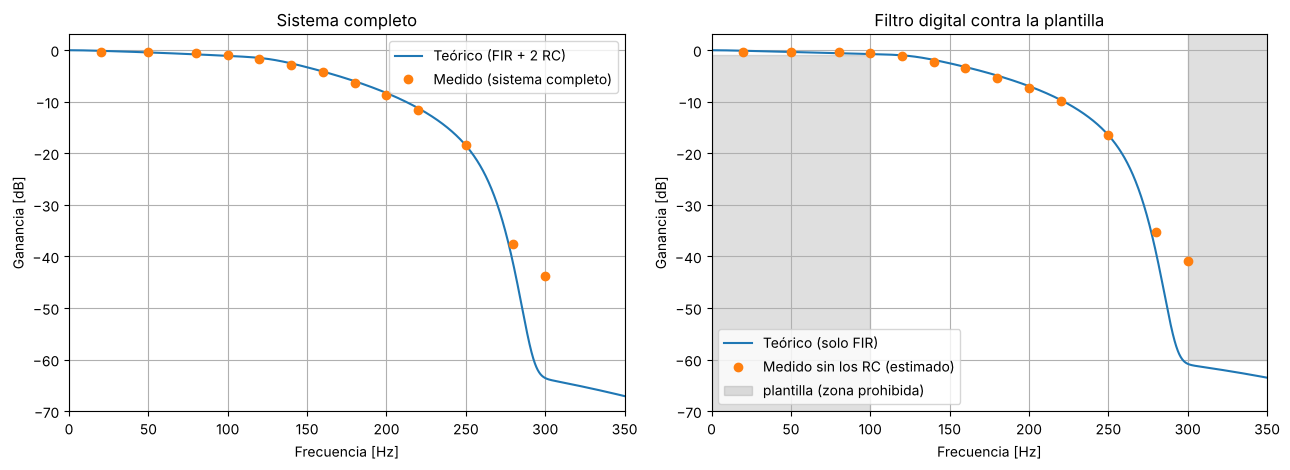

In [14]:
def plantilla_pb_hz(ax):
    """Zonas prohibidas de la plantilla A (pasa bajos), en Hz y dB."""
    ax.fill_between([0, fp], -alpha_max, -120, color='gray', alpha=0.25)
    ax.fill_between([fst, nyq], -alpha_min, 10, color='gray', alpha=0.25, label='plantilla (zona prohibida)')

f_t = np.linspace(1, nyq, 4000)
_, h_t = sig.freqz(taps_A, 1, worN=f_t, fs=fs_real)
G_fir_t = 20*np.log10(np.abs(h_t) + 1e-15)
G_sis_t = G_fir_t + 2*G_rc_dB(f_t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

ax1.plot(f_t, G_sis_t, label='Teórico (FIR + 2 RC)')
ax1.plot(medicion_A["freq"], medicion_A["G_med_dB"], 'o', label='Medido (sistema completo)')
ax1.set_xlim(0, 350); ax1.set_ylim(-70, 3)
ax1.set_xlabel('Frecuencia [Hz]'); ax1.set_ylabel('Ganancia [dB]')
ax1.set_title('Sistema completo'); ax1.grid(True); ax1.legend()

ax2.plot(f_t, G_fir_t, label='Teórico (solo FIR)')
ax2.plot(medicion_A["freq"], medicion_A["G_FIR_estimado_dB"], 'o', label='Medido sin los RC (estimado)')
plantilla_pb_hz(ax2)
ax2.set_xlim(0, 350); ax2.set_ylim(-70, 3)
ax2.set_xlabel('Frecuencia [Hz]'); ax2.set_ylabel('Ganancia [dB]')
ax2.set_title('Filtro digital contra la plantilla'); ax2.grid(True); ax2.legend()
plt.tight_layout(); plt.show()

**Resultado:**

- **Banda de paso:** en $f_p$ = 100 Hz se midió una ganancia de -0.98 dB en el sistema completo. De ese valor, unos 0.35 dB corresponden a los dos RC, así que el filtro digital aporta aproximadamente -0.63 dB, dentro de los 1 dB permitidos. La plantilla se evalúa sobre el filtro digital solo: el sistema completo, que incluye los dos RC, tiene en 100 Hz una caída teórica de 1.14 dB (medida: 0.98 dB). La curva medida sigue a la teórica con diferencias menores a 0.5 dB entre 20 y 250 Hz.
- **Banda de transición:** entre 100 y 250 Hz la caída medida (2.9 dB en 140 Hz, 8.6 dB en 200 Hz y 18.4 dB en 250 Hz) coincide con la teórica dentro de 0.5 dB, que es del orden de la resolución de lectura del osciloscopio (unos ±0.1 dB). En 280 Hz la diferencia ya es de unos 4 dB (se midieron 37.7 dB contra 41.7 dB teóricos).
- **Banda de stop:** en $f_s$ = 300 Hz se midió una atenuación de 43.7 dB en el sistema completo (unos 41 dB atribuibles al filtro digital), contra los 60 dB de la plantilla (la teoría da 60.8 dB para el FIR y 63.6 dB con los RC). Por lo tanto, **con estas mediciones no se logra verificar el cumplimiento de los 60 dB**. La salida en esa frecuencia es de apenas 20 a 40 mV pico a pico sobre una entrada de 3 V, cerca de la resolución del osciloscopio y de lo que pueden aportar el ruido de la red de 50 Hz y el ruido de cuantización y de reconstrucción del ADC y el DAC. Es probable que el valor medido esté limitado por ese piso y no por el filtro, pero no se verificó: para confirmarlo habría que medir la salida con la entrada en cero y comparar contra los 3 mV (pico a pico) que se esperan a 300 Hz si se cumplen los 60 dB.

#### 7.3.1 Captura con el analizador de audio

Con el mismo filtro FIR se registró también la respuesta con el analizador de audio, en un barrido de 10 a 500 Hz con eje de frecuencia logarítmico y escala vertical de 8 dB/div.

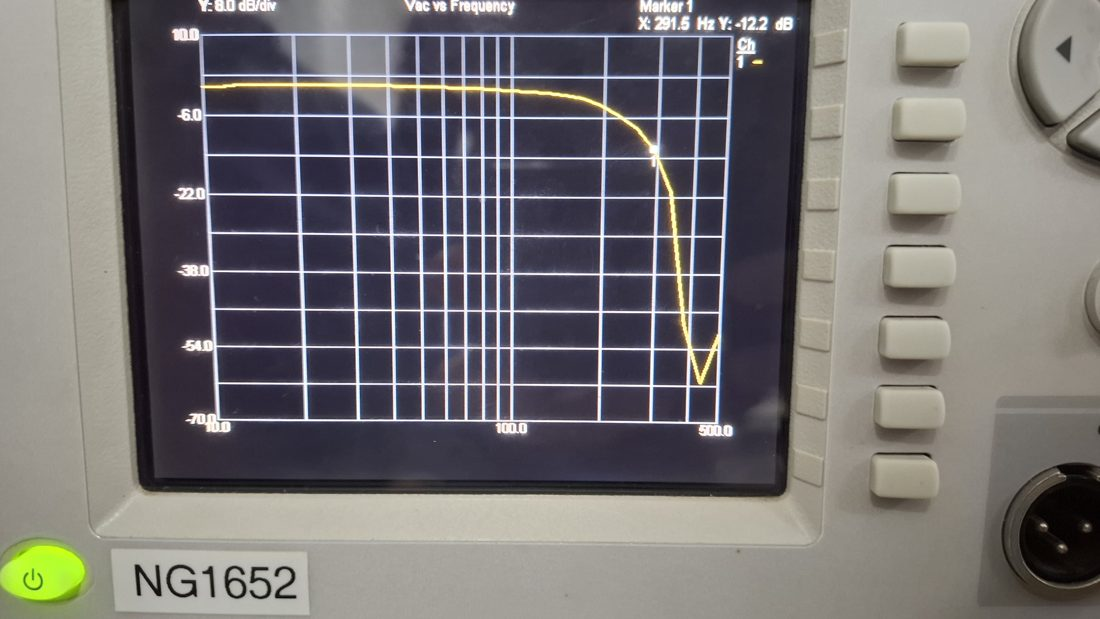

| Dato leído en la captura | Valor |
|---|---|
| Rango de frecuencia | 10 a 500 Hz (escala logarítmica) |
| Escala vertical | 8 dB/div |
| Marcador 1 | 291.5 Hz, -12.2 dB |

La captura muestra una banda de paso plana con una caída de aproximadamente 1 dB alrededor de 100 Hz, que coincide con la tabla medida con osciloscopio. A frecuencias mayores la curva cae más tarde que en la tabla: en la captura la atenuación es de aproximadamente 3 dB en 200 Hz y de 12.2 dB en 291.5 Hz, mientras que en la tabla (y en la respuesta teórica) es de 8.6 dB en 200 Hz y de 37.7 dB en 280 Hz. Por encima de unos 300 Hz la curva baja con pendiente muy pronunciada hasta un mínimo de aproximadamente -62 dB cerca de 430 Hz, y luego vuelve a subir.

**Criterio adoptado:** la medición principal del informe es la tabla tomada punto a punto con generador de funciones y osciloscopio (sección 7.3), porque coincide con la respuesta teórica dentro de 0.5 dB hasta 250 Hz. La captura del analizador no coincide en la zona de transición. No se conoce la configuración que tenía el analizador durante el barrido (tiempo de espera por punto), por lo que no se puede asegurar que cada punto se haya medido con la salida ya estabilizada. Una posibilidad, que no se verificó, está en la forma en que trabaja el micro: procesa la señal por bloques de 1024 muestras (1.024 s a 1 kHz) con dos buffers, de modo que la salida llega con un retraso de aproximadamente 2 s respecto de la entrada. Si el analizador cambia de frecuencia con poca espera, mide la salida correspondiente a la frecuencia anterior, y eso desplaza la curva hacia frecuencias más altas, como se observa. Esto podría afectar también a la medición punto a punto si el tiempo de espera tras cada cambio de frecuencia fue corto (el retardo de 64.5 muestras del propio FIR es despreciable frente a este). Queda como trabajo a futuro repetir el barrido con más tiempo de espera en cada frecuencia.

## 8. Comparación entre lo teórico y lo medido

In [15]:
f100 = medicion_A[medicion_A["freq"] == 100].iloc[0]
f300 = medicion_A[medicion_A["freq"] == 300].iloc[0]
caida_teo, att_teo = verificar_fir(taps_A, fs_real)

resumen = pd.DataFrame([
    ["A", "Caída en banda de paso (hasta 100 Hz)", "<= 1 dB",
     f"{caida_teo:.2f} dB", f"{-f100['G_med_dB']:.2f} dB (sistema)  /  {-f100['G_FIR_estimado_dB']:.2f} dB (filtro digital)", "Cumple"],
    ["A", "Atenuación en 300 Hz", ">= 60 dB",
     f"{att_teo:.1f} dB", f"{-f300['G_med_dB']:.1f} dB (sistema)  /  {-f300['G_FIR_estimado_dB']:.1f} dB (filtro digital)", "No verificable (piso de medición)"],
    ["B", "Frecuencia del notch", "50 Hz",
     f"{(bajo.max() + bajo.min())/2:.2f} Hz", "Mínimo en 50 Hz (resolución del barrido: 1 Hz)", "Cumple"],
    ["B", "Ancho de banda a -3 dB", "1 Hz",
     f"{bajo.max() - bajo.min():.3f} Hz", "No medido (paso del barrido: 1 Hz)", "Pendiente"],
    ["B", "Atenuación en 50 Hz", "(no especificada)",
     "> 200 dB (límite numérico)", f"{-fila50['G_med_dB']:.1f} dB (limitada por la precisión de la frecuencia de excitación y del centro real, ver 7.2.1)", "Compatible con la teoría"],
], columns=["Filtro", "Parámetro", "Especificación", "Teórico", "Medido", "Estado"])
resumen

,Filtro,Parámetro,Especificación,Teórico,Medido,Estado
0,A,Caída en banda de paso (hasta 100 Hz),<= 1 dB,0.79 dB,0.98 dB (sistema) / 0.63 dB (filtro digital),Cumple
1,A,Atenuación en 300 Hz,>= 60 dB,60.8 dB,43.7 dB (sistema) / 41.0 dB (filtro digital),No verificable (piso de medición)
2,B,Frecuencia del notch,50 Hz,50.00 Hz,Mínimo en 50 Hz (resolución del barrido: 1 Hz),Cumple
3,B,Ancho de banda a -3 dB,1 Hz,1.002 Hz,No medido (paso del barrido: 1 Hz),Pendiente
4,B,Atenuación en 50 Hz,(no especificada),> 200 dB (límite numérico),15.4 dB (limitada por la precisión de la frecu...,Compatible con la teoría


En el filtro A hasta 250 Hz y en el notch fuera de su centro, la respuesta medida coincide con la teoría (diferencias menores a 0.5 dB) una vez que se incorpora el aporte de los dos filtros RC analógicos: unos -0.4 dB a 110 Hz, que se verificó en modo `TALKTHROUGH`, y -2.8 dB a 300 Hz. En el filtro A, la captura con el analizador de audio no coincide con la tabla en la zona de transición (7.3.1), por lo que se adoptó la tabla punto a punto como medición principal. Las dos verificaciones que no se lograron cerrar con las mediciones (la atenuación de 60 dB en 300 Hz y el ancho de banda de 1 Hz del notch) están limitadas por el instrumental y por el paso del barrido, no por una discrepancia observada en el diseño.

## 9. Inconvenientes durante la puesta en marcha

- **Conexión del filtro interpolador.** En un primer armado el filtro pasa bajos de salida quedó conectado en una posición equivocada respecto del DAC. Se corrigió dejando la resistencia en serie con el pin del DAC y el capacitor del nodo de salida a masa, como en la sección 5.1.
- **Atenuación inesperada en modo TALKTHROUGH.** En una primera etapa la salida del sistema aparecía fuertemente atenuada (alrededor de 5 a 7 dB, incluso a baja frecuencia) aun sin filtrado digital. Se evaluó el efecto de la impedancia de fuente de 6.8 kΩ sobre la entrada del ADC (tiempo de muestreo) y la conexión de masa. La atenuación desapareció después de reiniciar por completo la alimentación de la placa (desconectando y volviendo a conectar el USB), y la causa exacta no pudo determinarse con certeza.
- **Falta de señal en la salida.** En algún momento el micro dejó de generar salida. Se usó el pin PC8, haciendo conmutar un GPIO dentro del callback del ADC, para comprobar que las conversiones se estaban disparando (una onda cuadrada de 500 Hz indica que lo hacen a 1 kHz). El problema también se resolvió con un reinicio completo de la alimentación.
- **Errores de conexión del ST-LINK al programar,** resueltos reconectando el USB y desconectando las puntas de prueba durante la programación.

La principal lección es validar la cadena en modo `TALKTHROUGH` antes de medir cualquier filtro: permite separar los efectos del hardware analógico y de la adquisición de lo que realmente hace el filtro digital.

## 10. Conclusiones

Se diseñaron, implementaron y midieron dos filtros digitales sobre una NUCLEO-F446RE con CMSIS-DSP: el filtro A (pasa bajos, plantilla Chebyshev) como FIR de 130 coeficientes con ventana Kaiser ($\beta=14$), y el filtro B (notch de 50 Hz) como IIR de una sola sección de segundo orden. Los coeficientes dependen de la frecuencia de muestreo, por lo que el diseño se programó con `fs_real` como parámetro. Los del IIR se convierten de signo para CMSIS y los del FIR se cargan sin cambios.

**Filtro A.** El diseño cumple la plantilla (0.79 dB de caída en banda de paso y 60.8 dB de atenuación en 300 Hz) y tiene fase lineal. En la medición, la banda de paso cumple (alrededor de -0.63 dB para el filtro digital en 100 Hz, con el límite en 1 dB) y la transición sigue a la teoría hasta 250 Hz. Hacia la banda de stop la medición se aparta (4 dB en 280 Hz y unos 20 dB en 300 Hz), y la atenuación de 60 dB no pudo verificarse (se midieron 43.7 dB en 300 Hz).

**Filtro B.** El diseño da un ancho de banda de 1.00 Hz a -3 dB. En la medición el mínimo aparece en 50 Hz (50.2 Hz en el barrido con el analizador), con 15.4 dB de atenuación punto a punto y 19.9 dB en el barrido. Que no sea más profunda se explica por lo angosto del filtro: es muy sensible a la frecuencia exacta de excitación y al tiempo de espera tras cada cambio. Fuera del centro, el notch sigue a la teoría dentro de 0.5 dB.

**Pendiente.** Para cerrar las verificaciones faltantes queda: medir el piso de ruido de la salida (60 dB del filtro A), medir la frecuencia de muestreo real del micro, y barrer el entorno de 50 Hz con pasos más finos y esperando varios segundos en cada punto (ancho de banda y profundidad del notch).